# 02 · Naive Bayes
Loads pre-built features → tunes `alpha` on the **validation set** → evaluates on the held-out **test set**.

**Prerequisite:** `01_features_ml.ipynb`

In [6]:
import os, pickle, warnings, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
warnings.filterwarnings('ignore')

INPUT_DIR = '../outputs/featured/'
OUTPUT_DIR = '../outputs/nb/'

os.makedirs(OUTPUT_DIR, exist_ok=True)

def load(name):
    with open(os.path.join(INPUT_DIR, f'{name}.pkl'), 'rb') as f:
        return pickle.load(f)

X_train = load('X_nb_feat_train')
X_val   = load('X_nb_feat_val')
X_test  = load('X_nb_feat_test')
y_train = load('y_train_np')
y_val   = load('y_val_np')
y_test  = load('y_test_np')

print(f'Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}')


Train: 27052 | Val: 5797 | Test: 5797


## 1 · Hyperparameter Tuning on Validation Set
Grid-search `alpha` values; pick the one that maximises **validation F1**.

In [7]:
alphas = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0]
val_scores = {}

for alpha in alphas:
    clf = ComplementNB(alpha=alpha)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_val)
    f1 = f1_score(y_val, preds, average='weighted')
    val_scores[alpha] = f1
    print(f'  alpha={alpha:.2f}  Val F1={f1:.4f}')

best_alpha = max(val_scores, key=val_scores.get)
print(f'\nBest alpha: {best_alpha}  (Val F1={val_scores[best_alpha]:.4f})')


  alpha=0.01  Val F1=0.9562
  alpha=0.05  Val F1=0.9534
  alpha=0.10  Val F1=0.9528
  alpha=0.50  Val F1=0.9493
  alpha=1.00  Val F1=0.9479
  alpha=2.00  Val F1=0.9430

Best alpha: 0.01  (Val F1=0.9562)


## 2 · Train Final Model with Best Alpha

In [8]:
nb = ComplementNB(alpha=best_alpha)
nb.fit(X_train, y_train)
print('Model trained.')

Model trained.


## 3 · Evaluate on Test Set


=== Naive Bayes ===
  Accuracy  : 0.9503
  Precision : 0.9506
  Recall    : 0.9503
  F1        : 0.9504

              precision    recall  f1-score   support

        Fake       0.94      0.96      0.95      2619
        Real       0.96      0.95      0.95      3178

    accuracy                           0.95      5797
   macro avg       0.95      0.95      0.95      5797
weighted avg       0.95      0.95      0.95      5797



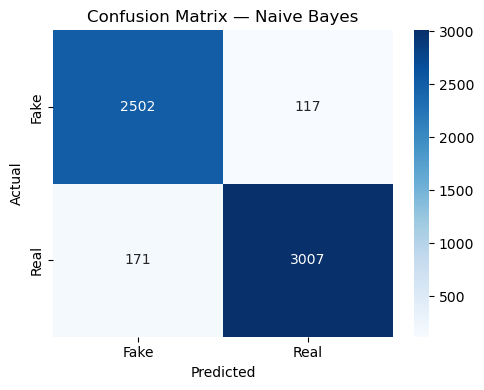

In [9]:
def evaluate(name, y_true, y_pred):
    metrics = dict(
        Accuracy  = accuracy_score(y_true, y_pred),
        Precision = precision_score(y_true, y_pred, average='weighted'),
        Recall    = recall_score(y_true, y_pred, average='weighted'),
        F1        = f1_score(y_true, y_pred, average='weighted'),
    )
    print(f'\n=== {name} ===')
    for k, v in metrics.items():
        print(f'  {k:10s}: {v:.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=['Fake', 'Real']))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fake','Real'], yticklabels=['Fake','Real'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'cm_{name.replace(" ","_")}.png'), dpi=120)
    plt.show()
    return metrics

y_pred_nb = nb.predict(X_test)
metrics_nb = evaluate('Naive Bayes', y_test, y_pred_nb)


## 4 · Save Model & Predictions

In [10]:
joblib.dump(nb, os.path.join(OUTPUT_DIR, 'model_naive_bayes.pkl'))

with open(os.path.join(OUTPUT_DIR, 'pred_naive_bayes.pkl'), 'wb') as f:
    pickle.dump(y_pred_nb, f)

with open(os.path.join(OUTPUT_DIR, 'metrics_naive_bayes.json'), 'w') as f:
    json.dump({'best_alpha': best_alpha, 'val_scores': val_scores, 'test': metrics_nb}, f, indent=2)

print('Saved: model_naive_bayes.pkl, pred_naive_bayes.pkl, metrics_naive_bayes.json')


Saved: model_naive_bayes.pkl, pred_naive_bayes.pkl, metrics_naive_bayes.json
